# Tunoe Field Inversion - Minimal Workflow

Load Tunoe station data, plot the soundings and survey map, invert every
station, and plot the recovered
resistivity section.

In [1]:
import sys, os, time
from pathlib import Path
import concurrent.futures as _cf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import display

# Locate the pyTEM repo root (the folder containing the `pytem` package) by
# searching upward from the working directory, so no absolute path is needed.
ROOT = None
for _root in [Path.cwd(), *Path.cwd().parents]:
    if (_root / "pytem").is_dir():
        ROOT = str(_root)
        break
if ROOT and ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from pytem import (
    read_usf, Survey, setup_shared_gate_matrices, invert_joint, plot_model,
)

try:
    import numba as _numba
except Exception:
    _numba = None


## 1. Load data

In [2]:
USF_DIR = Path(
    r"C:\Users\pamcl\OneDrive - Danmarks Tekniske Universitet\Dokumenter\Projects_Sorted\Current\Denmark\Tunoe\raw\Tunoe\Data\USF_Files_Tunoe"
)

tem = read_usf(USF_DIR)
surv = Survey(tem)

print(f"Soundings : {len(tem.data)}")
for m in surv.moments:
    print(f"  {m}: {len(tem.gate_times[m]['center'])} gates  "
          f"[{tem.gate_times[m]['center'][0]:.2e} ... {tem.gate_times[m]['center'][-1]:.2e}] s")


Soundings : 17
  LM: 8 gates  [1.23e-05 ... 5.33e-05] s
  HM: 21 gates  [2.51e-05 ... 2.36e-03] s


## 1b. Select stations to use

Manually list stations whose data will not be carried forward (e.g. a field
note about a nearby noise source, or a sounding cut short in the field).


In [3]:
MANUAL_BAD_IDX = [3, 13]   # add station indices here to exclude them, e.g. after inspecting the plots
# remember 0 is 1, 1 is 2...
MAX_NOISE = 0.50   # per-gate fractional noise above this is bad data (dropped from plots + inversion)

exclude_idx = np.asarray(sorted(MANUAL_BAD_IDX), dtype=int)
use_idx = np.setdiff1d(np.arange(len(tem.data)), exclude_idx)

print(f"Use ({use_idx.size}/{len(tem.data)}): "
      f"{list(tem.data['SoundingName'].iloc[use_idx])}")
print(f"Exclude ({exclude_idx.size}/{len(tem.data)}): "

      f"{list(tem.data['SoundingName'].iloc[exclude_idx])}")

Use (15/17): ['Line001_001', 'Line001_002', 'Line001_003', 'Line001_005', 'Line001_006', 'Line001_007', 'Line001_009', 'Line001_011', 'Line001_012', 'Line001_013', 'Line001_014', 'Line001_015', 'Line001_017', 'Line001_018', 'Line001_019']
Exclude (2/17): ['Line001_004', 'Line001_016']


In [4]:
lm_df = pd.DataFrame(tem.dbdt('LM'), index=tem.data['SoundingName'],
                     columns=tem.gate_times['LM']['center'])
hm_df = pd.DataFrame(tem.dbdt('HM'), index=tem.data['SoundingName'],
                     columns=tem.gate_times['HM']['center'])

print('LM data [V/(A*m^2)], columns = gate centre time [s]')
display(lm_df)
print('HM data [V/(A*m^2)], columns = gate centre time [s]')
display(hm_df)


LM data [V/(A*m^2)], columns = gate centre time [s]


,0.000012,0.000015,0.000019,0.000023,0.000028,0.000035,0.000043,0.000053
SoundingName,,,,,,,,
Line001_001,1.186133e-06,7.636582e-07,4.948167e-07,3.204564e-07,2.065608e-07,1.309889e-07,8.237940e-08,5.149339e-08
Line001_002,9.512860e-07,5.667941e-07,3.381491e-07,2.127241e-07,1.298454e-07,8.178167e-08,5.000470e-08,3.049586e-08
Line001_003,8.697619e-07,4.886171e-07,2.773882e-07,1.604976e-07,9.556416e-08,5.875786e-08,3.761851e-08,2.448270e-08
Line001_004,-2.824473e-06,6.201105e-06,-7.041032e-07,5.990169e-07,9.380108e-07,2.914038e-07,3.017067e-07,3.245380e-07
Line001_005,1.168839e-06,7.556496e-07,4.940938e-07,3.221003e-07,2.070710e-07,1.300349e-07,7.946924e-08,4.596497e-08
Line001_006,8.939511e-07,4.986242e-07,2.833539e-07,1.628864e-07,9.445068e-08,5.553933e-08,3.333243e-08,1.947466e-08
Line001_007,7.079532e-07,4.193335e-07,2.506955e-07,1.488749e-07,8.724493e-08,5.106935e-08,3.036835e-08,1.762055e-08
Line001_009,7.246299e-07,4.278021e-07,2.560800e-07,1.524179e-07,8.954237e-08,5.223111e-08,3.047187e-08,1.747568e-08
Line001_011,7.279593e-07,4.291484e-07,2.568404e-07,1.528181e-07,8.969986e-08,5.224356e-08,3.058028e-08,1.745019e-08


HM data [V/(A*m^2)], columns = gate centre time [s]


,0.000025,0.000031,0.000040,0.000050,0.000062,0.000078,0.000098,0.000123,0.000154,0.000194,...,0.000305,0.000383,0.000481,0.000603,0.000757,0.000950,0.001192,0.001496,0.001878,0.002356
SoundingName,,,,,,,,,,,,,,,,,,,,,
Line001_001,3.233143e-07,1.983428e-07,1.212953e-07,7.406322e-08,4.540193e-08,2.774077e-08,1.689936e-08,1.051258e-08,6.449023e-09,4.169350e-09,...,1.717964e-09,1.131348e-09,7.012355e-10,4.548158e-10,3.029949e-10,1.835129e-10,1.092512e-10,7.190401e-11,4.038142e-11,2.660971e-11
Line001_002,2.169044e-07,1.277909e-07,7.836437e-08,4.785169e-08,3.068317e-08,2.057609e-08,1.327020e-08,8.358358e-09,5.707099e-09,4.121559e-09,...,1.486679e-09,7.678700e-10,4.279629e-10,3.481742e-10,4.118412e-10,2.053187e-10,1.221132e-10,7.409706e-11,2.241306e-11,2.412779e-11
Line001_003,1.636890e-07,9.340521e-08,5.687379e-08,3.663073e-08,2.452088e-08,1.699883e-08,1.191711e-08,8.252725e-09,5.807224e-09,3.809068e-09,...,1.557054e-09,1.159291e-09,8.050860e-10,4.756457e-10,3.248171e-10,1.877520e-10,1.228361e-10,6.250900e-11,4.984356e-11,3.209857e-11
Line001_004,4.657222e-07,7.369469e-07,3.806059e-07,3.277249e-07,2.401725e-07,1.903301e-07,1.319409e-07,8.189128e-08,9.135277e-09,-3.763471e-08,...,5.582536e-09,2.506328e-08,5.346652e-09,1.383859e-09,4.486566e-09,2.340774e-09,1.728866e-09,1.315905e-09,9.333460e-10,6.065334e-10
Line001_005,3.212926e-07,1.945994e-07,1.152611e-07,6.611289e-08,3.647071e-08,1.949470e-08,1.044947e-08,5.997865e-09,3.923294e-09,2.427134e-09,...,9.309461e-10,7.111185e-10,4.884266e-10,2.866240e-10,2.022097e-10,1.277466e-10,8.200692e-11,5.099779e-11,3.195729e-11,1.922063e-11
Line001_006,1.618948e-07,8.860037e-08,5.009820e-08,2.925163e-08,1.767096e-08,1.103276e-08,7.100453e-09,4.723512e-09,3.198537e-09,2.150456e-09,...,9.870512e-10,6.865241e-10,4.383347e-10,2.980619e-10,1.995998e-10,1.254188e-10,8.265296e-11,4.835163e-11,2.874836e-11,1.718127e-11
Line001_007,1.573992e-07,8.629368e-08,4.774513e-08,2.698661e-08,1.570957e-08,9.498840e-09,6.031583e-09,3.919236e-09,2.643274e-09,1.803002e-09,...,8.654075e-10,6.129535e-10,4.180313e-10,2.710258e-10,1.806306e-10,1.220496e-10,7.495671e-11,5.019848e-11,3.132863e-11,1.930395e-11
Line001_009,1.522542e-07,8.398260e-08,4.676622e-08,2.658784e-08,1.561688e-08,9.371115e-09,5.973858e-09,3.882051e-09,2.626372e-09,1.783147e-09,...,8.723841e-10,6.081912e-10,4.068770e-10,2.776164e-10,1.862923e-10,1.204912e-10,7.692267e-11,4.870140e-11,3.039271e-11,1.795331e-11
Line001_011,1.513257e-07,8.368946e-08,4.668674e-08,2.649622e-08,1.548827e-08,9.438384e-09,5.905898e-09,3.903132e-09,2.623756e-09,1.816185e-09,...,8.719383e-10,6.011509e-10,4.174042e-10,2.771527e-10,1.895239e-10,1.198484e-10,7.940920e-11,4.961728e-11,3.013939e-11,1.854070e-11


## 2b. Plot signal vs distance along line

All gate times plotted against distance along the line (each station is a
point at its own distance), to spot lateral trends. Set `TRANSECT_X_AXIS`
to `'index'` to use station order instead of distance.


array([<Axes: title={'center': 'Line 001'}, xlabel='Station index', ylabel='|dB/dt| (HM)'>],
      dtype=object)

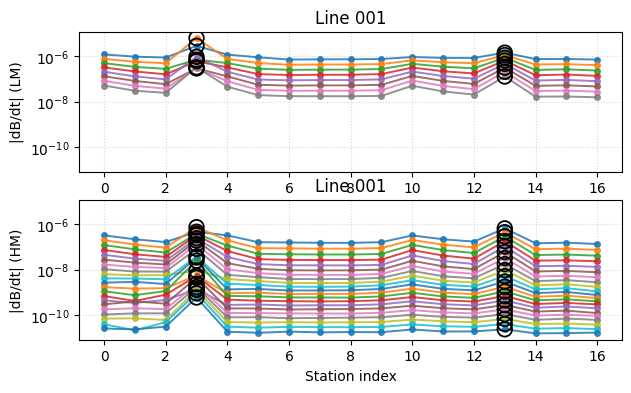

In [5]:
TRANSECT_X_AXIS = 'index'   # 'distance' (along line, m) or 'index' (station order)

n_lines = len(tem.lines())


def bad_gate_mask(moment):
    """(n_stations, n_gates) bool: True for stations excluded in section 1b."""
    n_gates = tem.dbdt(moment).shape[1]
    mask = np.zeros((len(tem.data), n_gates), dtype=bool)
    mask[exclude_idx] = True
    return mask

fig, axs = plt.subplots(2, 1, figsize=(7, 4), sharey=True)
surv.plot_transects('LM', axes=axs[0], n_gates=len(tem.gate_times['LM']['center']),
                    x_axis=TRANSECT_X_AXIS, bad_mask=bad_gate_mask('LM'), 
                    legend=False)
surv.plot_transects('HM', axes=axs[1], n_gates=len(tem.gate_times['HM']['center']),
                    x_axis=TRANSECT_X_AXIS, bad_mask=bad_gate_mask('HM'),
                    legend=False)

## 3. Plot map

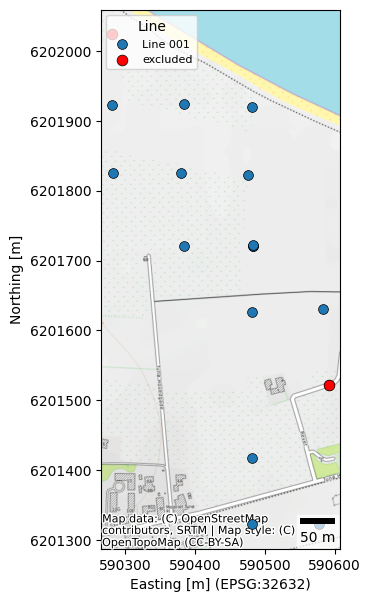

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))
surv.plot_map(ax=ax)
e, n, _ = tem.utm_coords()
ax.scatter(e[exclude_idx], n[exclude_idx], c='red', s=60, zorder=5,
          edgecolors='k', linewidths=0.5, label='excluded')
ax.legend(title='Line', fontsize=8, loc='upper left', framealpha=0.8)
plt.show()


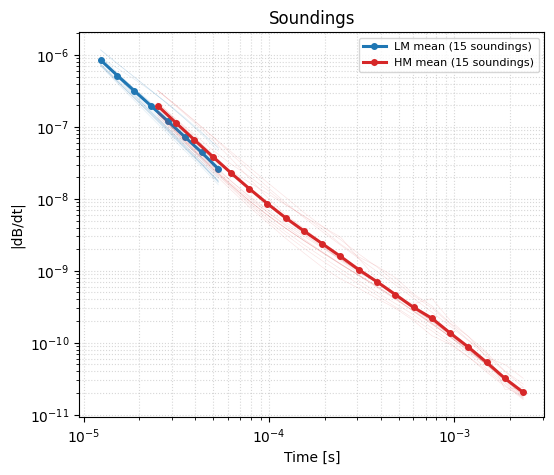

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
surv.plot_soundings(ax=ax, station_mask=use_idx)
plt.show()

## 4. Invert data

Each station's LM and HM soundings are fit jointly with `pytem.invert_joint()`
(Gauss-Newton + alpha search, gate box-car averaging, and the analytical
Jacobian all live in that one base-code function). The notebook only builds
the per-moment gate-averaging matrices (shared across all stations) and the
per-station fit systems handed to it.

In [8]:
# Survey / loop geometry
MOMENTS = ['LM', 'HM']
CURRENTS = {'LM': 1.0, 'HM': 10.0}
USE_SQUARE_LOOP = False   # False = equal-area circular offset loop; True = square offset loop

systems = {m: tem.to_pytem(m, peak_current=CURRENTS[m]) for m in MOMENTS}

tx_side = float(systems['HM']['tx_size'])
tx_radius_equal_area = float(np.sqrt(tx_side ** 2 / np.pi))
rx_x = abs(float(systems['HM']['rx_x']))
rx_y = abs(float(systems['HM']['rx_y']))
geometry_inv = 'square_offset' if USE_SQUARE_LOOP else 'circle_offset'
tx_size_inv = tx_side if USE_SQUARE_LOOP else tx_radius_equal_area

print(f"Geometry : {geometry_inv} | tx_size={tx_size_inv:.2f} m | rx=({rx_x:.2f}, {rx_y:.2f}) m")

Geometry : circle_offset | tx_size=1.69 m | rx=(13.00, 0.00) m


In [9]:
# Model grid and inversion settings
N_LAYERS = 15
thicknesses = np.logspace(np.log10(2.0), np.log10(25.0), N_LAYERS - 1)
depths_top = np.concatenate([[0.0], np.cumsum(thicknesses)])
rho_start = np.ones_like(depths_top) * 100.0

# Shared step-time grid + gate box-car averaging matrix per moment (built once,
# reused by every station): this is what recovers a physically sensible model 
shared_t_step, matrix_systems = setup_shared_gate_matrices(systems)

print(f"Shared step-time grid: {shared_t_step.size} points, "
      f"[{shared_t_step[0]:.2e}, {shared_t_step[-1]:.2e}] s")


Shared step-time grid: 300 points, [4.87e-07, 8.98e-02] s


In [10]:
RHO_MIN, RHO_MAX = 0.1, 1e5
ALPHA_STEPS = 5
ALPHA_STEP = 1 / 9
MAXIT = 15


def invert_station(station):
    """Fit one station: joint LM+HM inversion via pytem.invert_joint().

    Builds the per-moment gate-averaging fit systems (using the shared
    matrix_systems from setup_shared_gate_matrices), then hands them to the
    base ``pytem.invert_joint`` for the actual Gauss-Newton solve -- no
    solver code lives in this notebook. Returns extra diagnostics (iteration
    count, convergence flag, per-moment gate counts, observed vs modelled
    data) for reporting and QC plots.
    """
    if _numba is not None:
        try:
            _numba.set_num_threads(1)
        except Exception:
            pass

    fit_systems = []
    times_per_moment = {}
    for moment in MOMENTS:
        kw = tem.to_pytem(moment, peak_current=CURRENTS[moment], station=station)
        obs, noise, times = kw['obs_data'], kw['noise_std'], kw['times']
        good = np.isfinite(obs) & np.isfinite(noise) & (obs > 0) & (noise <= MAX_NOISE)
        noise_abs = np.maximum(noise[good], 0.05) * obs[good]
        fit_systems.append({'M': matrix_systems[moment][good], 'obs': obs[good], 'noise': noise_abs})
        times_per_moment[moment] = times[good]

    result = invert_joint(
        fit_systems, thicknesses, rho_start, shared_t_step, tx_size_inv, geometry_inv,
        rx_x=rx_x, rx_y=rx_y, rho_min=RHO_MIN, rho_max=RHO_MAX,
        alpha_steps=ALPHA_STEPS, alpha_step=ALPHA_STEP, maxit=MAXIT,
        use_numba=True, use_cuda=False, transform='dlf', verbose=False)

    splits = np.cumsum(result['n_gates'])[:-1]
    obs_per_moment = dict(zip(MOMENTS, np.split(result['observed'], splits)))
    pred_per_moment = dict(zip(MOMENTS, np.split(result['predicted'], splits)))

    return {
        'station': station,
        'resistivities': result['resistivities'],
        'rms': result['rms'],
        'n_iter': result['n_iter'],
        'converged': result['converged'],
        'n_gates': dict(zip(MOMENTS, result['n_gates'])),
        'times': times_per_moment,
        'obs': obs_per_moment,
        'pred': pred_per_moment,
    }



Invert every station (parallel, one worker per station up to 8 threads).

In [11]:
N_WORKERS = min(os.cpu_count() or 4, 8)
n_stations = int(tem.data.shape[0])
station_ids = use_idx.tolist()   # skip stations flagged in section 1b

rho_sections = np.full((n_stations, rho_start.size), np.nan)
rms_stations = np.full(n_stations, np.nan)
station_results = {}   # station -> full invert_station() result dict (for QC plots below)

t0 = time.perf_counter()
with _cf.ThreadPoolExecutor(max_workers=min(N_WORKERS, len(station_ids))) as executor:
    for res in executor.map(invert_station, station_ids):
        station = res['station']
        rho_sections[station] = res['resistivities']
        rms_stations[station] = res['rms']
        station_results[station] = res
        status = 'ok' if res['converged'] else 'NOT CONVERGED'
        gates = ', '.join(f'{m}={n}' for m, n in res['n_gates'].items())
        print(f"station {station:02d} ({tem.data['SoundingName'].iloc[station]:>14s})  "
              f"RMS={res['rms']:.3f}  iters={res['n_iter']:>2d}  {status:<14s}  gates: {gates}")
print(f'Inverted {len(station_ids)}/{n_stations} stations in {time.perf_counter() - t0:.1f} s.')

summary = pd.DataFrame([
    {'SoundingName': tem.data['SoundingName'].iloc[s], 'RMS': r['rms'],
     'n_iter': r['n_iter'], 'converged': r['converged'], **r['n_gates']}
    for s, r in sorted(station_results.items())
])
display(summary)

station 00 (   Line001_001)  RMS=0.904  iters= 5  ok              gates: LM=8, HM=21
station 01 (   Line001_002)  RMS=1.297  iters=11  NOT CONVERGED   gates: LM=8, HM=20
station 02 (   Line001_003)  RMS=0.984  iters= 7  ok              gates: LM=8, HM=21
station 04 (   Line001_005)  RMS=1.000  iters= 8  ok              gates: LM=8, HM=21
station 05 (   Line001_006)  RMS=0.874  iters= 5  ok              gates: LM=8, HM=21
station 06 (   Line001_007)  RMS=1.000  iters= 4  ok              gates: LM=8, HM=21
station 07 (   Line001_009)  RMS=0.897  iters= 5  ok              gates: LM=8, HM=21
station 08 (   Line001_011)  RMS=0.935  iters= 5  ok              gates: LM=8, HM=21
station 09 (   Line001_012)  RMS=0.975  iters= 5  ok              gates: LM=8, HM=21
station 10 (   Line001_013)  RMS=0.901  iters= 8  ok              gates: LM=8, HM=21
station 11 (   Line001_014)  RMS=0.909  iters= 6  ok              gates: LM=8, HM=21
station 12 (   Line001_015)  RMS=0.899  iters= 5  ok             

,SoundingName,RMS,n_iter,converged,LM,HM
0,Line001_001,0.904409,5,True,8,21
1,Line001_002,1.296913,11,False,8,20
2,Line001_003,0.983673,7,True,8,21
3,Line001_005,0.999780,8,True,8,21
4,Line001_006,0.874155,5,True,8,21
5,Line001_007,0.999589,4,True,8,21
6,Line001_009,0.896945,5,True,8,21
7,Line001_011,0.934911,5,True,8,21
8,Line001_012,0.974506,5,True,8,21
9,Line001_013,0.901095,8,True,8,21


## 5. Show results

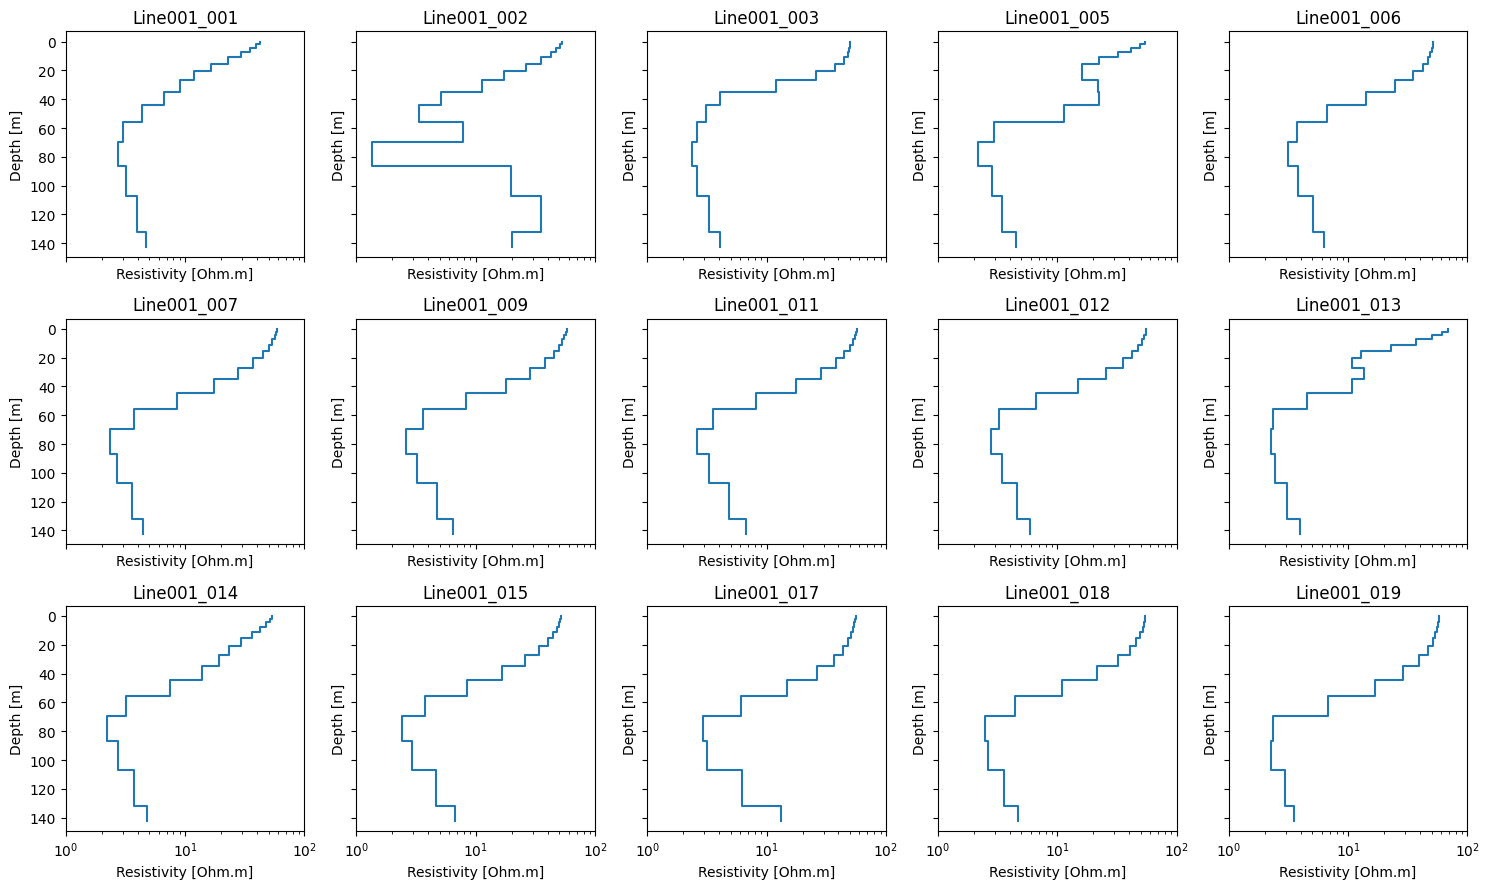

15/17 stations inverted, RMS range 0.874 to 1.297


In [12]:
valid = np.all(np.isfinite(rho_sections), axis=1) & np.isfinite(rms_stations)
station_idx = np.flatnonzero(valid)

N_COLS = 5
n_rows = int(np.ceil(station_idx.size / N_COLS))
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(3 * N_COLS, 3 * n_rows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, station in zip(axes, station_idx):
    plot_model(thicknesses, rho_sections[station], ax=ax, color='tab:blue',
              label=None, title=tem.data['SoundingName'].iloc[station], xlim=(1, 1e2))
for ax in axes[station_idx.size:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

rms_valid = rms_stations[valid]
print(f'{station_idx.size}/{n_stations} stations inverted, RMS range '
      f'{np.nanmin(rms_valid):.3f} to {np.nanmax(rms_valid):.3f}')


## 5b. Observed vs. modelled data

Per-station fit quality: measured dB/dt (points) against the final model's
response (lines), one subplot per station, LM/HM in their usual colours.


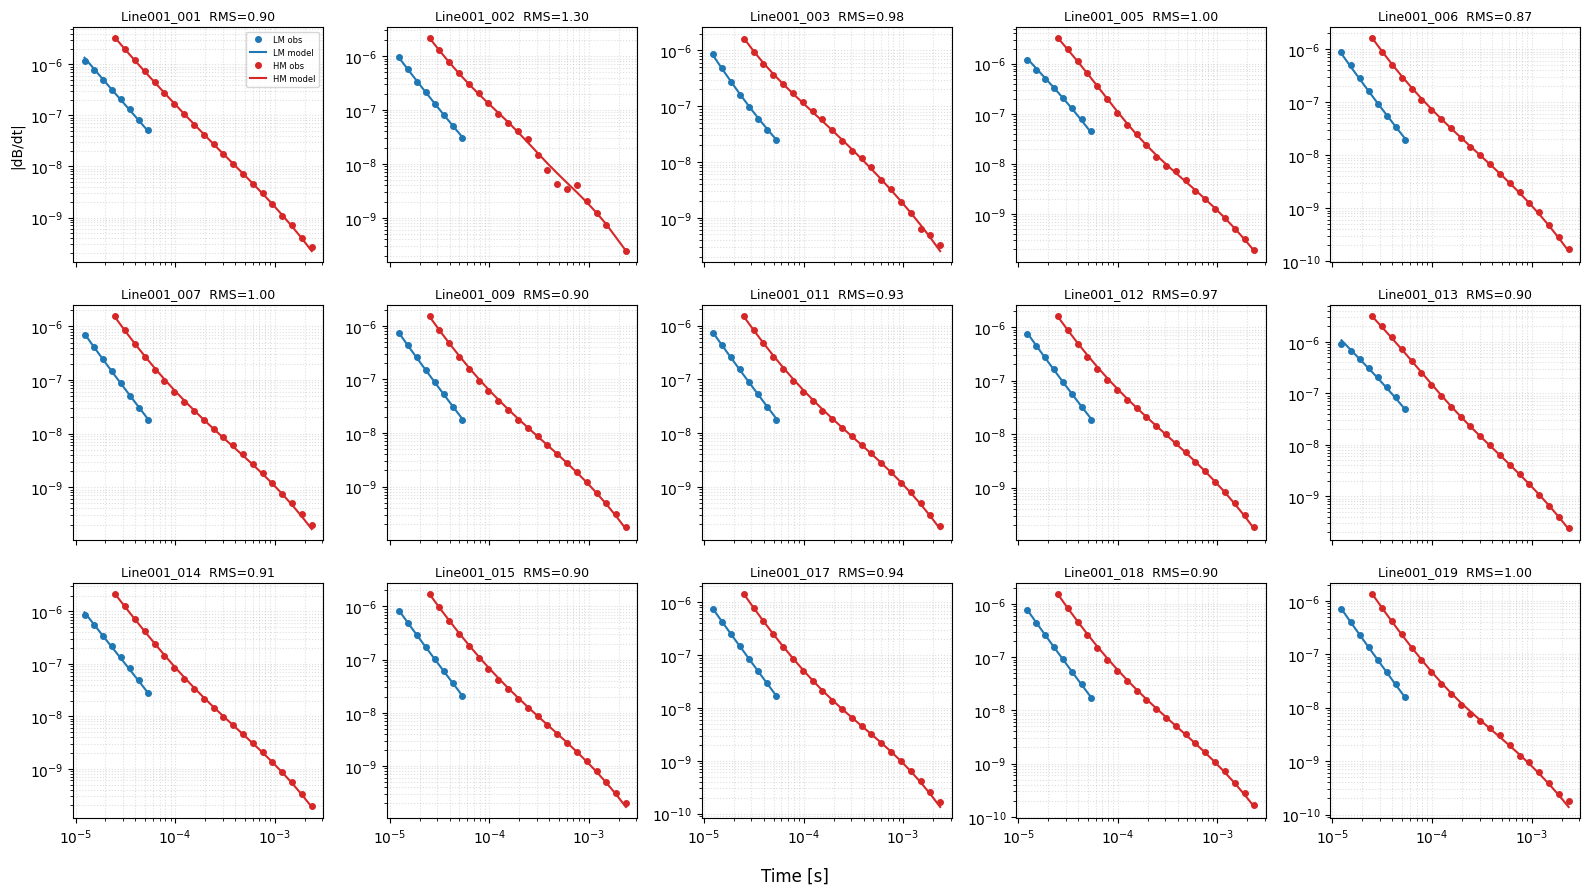

In [13]:
MOMENT_COLOR = {'LM': 'tab:blue', 'HM': 'tab:red'}

fig, axes = plt.subplots(n_rows, N_COLS, figsize=(3.2 * N_COLS, 3 * n_rows), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, station in zip(axes, station_idx):
    res = station_results[station]
    for moment in MOMENTS:
        color = MOMENT_COLOR[moment]
        ax.loglog(res['times'][moment], np.abs(res['obs'][moment]), 'o', ms=4,
                 color=color, label=f'{moment} obs')
        ax.loglog(res['times'][moment], np.abs(res['pred'][moment]), '-', lw=1.5,
                 color=color, label=f'{moment} model')
    ax.set_title(f"{tem.data['SoundingName'].iloc[station]}  RMS={res['rms']:.2f}", fontsize=9)
    ax.grid(True, which='both', ls=':', alpha=0.4)
for ax in axes[station_idx.size:]:
    ax.axis('off')

axes[0].set_ylabel('|dB/dt|')
axes[0].legend(fontsize=6)
fig.supxlabel('Time [s]')
plt.tight_layout()
plt.show()
